In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam

In [ ]:
(x_train, _), (_, _) =mnist.load_data()

x_train= (x_train - 127.5) / 127.5
x_train= np.expand_dims(x_train, axis =-1)
img_shape =(28,28,1)

In [ ]:
def build_generator():
  model= Sequential()

  model.add(Dense(128, input_dim=100))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(256))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(512))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(int(np.prod(img_shape)),activation='tanh'))
  model.add(Reshape(img_shape))

  return model



In [ ]:
def build_discriminator():
  model = Sequential()
  model.add(Flatten(input_shape= img_shape))

  model.add(Dense(512))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(256))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(1, activation='sigmoid'))
  return model

In [ ]:
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

discriminator= build_discriminator()
discriminator.compile(loss='binary_crossentropy',
                      optimizer=optimizer, metrics=['accuracy'])

generator = build_generator()
discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer=optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def build_generator():
    model = Sequential()
    model.add(Dense(128,input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(int(np.prod(img_shape)), activation='tanh'))
    model.add(Reshape(img_shape))
    return model

def build_discriminator():
  model = Sequential()
  model.add(Flatten(input_shape=img_shape))
  model.add(Dense(512))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dense(256))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Dense(1, activation='sigmoid'))
  return model

In [ ]:
from tensorflow.keras.optimizers import Adam
from IPython.core.interactiveshell import dis
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
discriminator = build_discriminator()

discriminator.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
generator = build_generator()
discriminator.trainable = False
gan = Sequential()
gan.add(generator)
gan.add(discriminator)
gan.compile(loss='binary_crossentropy', optimizer=optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def train(epochs, batch_size=64, save_interval=100):
  half_batch = int(batch_size//2)

  for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], half_batch)
    real_images = x_train[idx]

    noise=np.random.normal(0,1,(half_batch, 100))
    fake_images=generator.predict(noise)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    noise = np.random.normal(0, 1, (batch_size, 100))
    valid_y = np.array([1] * batch_size)

    g_loss = gan.train_on_batch(noise, valid_y)
    print(f"{epoch+1}/{epochs} [D loss: {d_loss[0]}, acc.: {100* d_loss[1]}] [G loss: {g_loss}]")
    if epoch % save_interval ==0:
      save_images(epoch)



In [ ]:
def save_images(epoch):
  r, c =5, 5
  noise = np.random.normal(0,1,(r*c,100))
  gen_images= generator.predict(noise)
  gen_images = 0.5 * gen_images+0.5
  fig,axs=plt.subplots(r,c)
  cnt=0
  for i in range(r):
    for j in range(c):
      axs[i,j].imshow(gen_images[cnt,:,:,0], cmap='gray')
      axs[i,j].axis('off')
      cnt+=1
  plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1000 [D loss: 0.8879480957984924, acc.: 22.91666603088379] [G loss: 0.6131778955459595]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


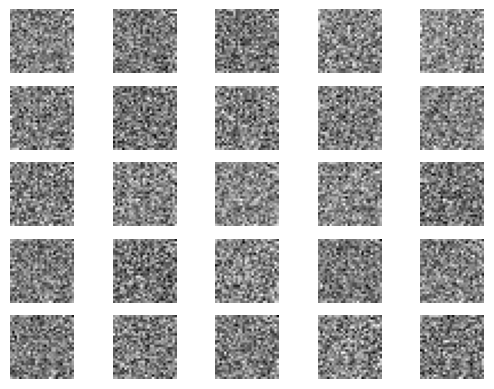

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/1000 [D loss: 0.9108777642250061, acc.: 19.25223159790039] [G loss: 0.5602260231971741]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3/1000 [D loss: 0.9516403079032898, acc.: 16.82291603088379] [G loss: 0.5141032934188843]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/1000 [D loss: 0.9921232461929321, acc.: 15.246212005615234] [G loss: 0.47042354941368103]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/1000 [D loss: 1.034428358078003, acc.: 14.835165023803711] [G loss: 0.432206392288208]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6/1000 [D loss: 1.082779884338379, acc.: 13.723957061767578] [G loss: 0.39610370993614197]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
7/1000 [D loss: 1.1338326930999756, acc.: 12.867647171020508] [G loss: 0.366323322057724]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
8/1000 [D loss: 1.1898040771484375, acc.: 12.027138710021973] [G loss: 0.3393808603286743]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
9/1000 [D loss: 1.2420413494110107, acc.: 11.634199142456055] [

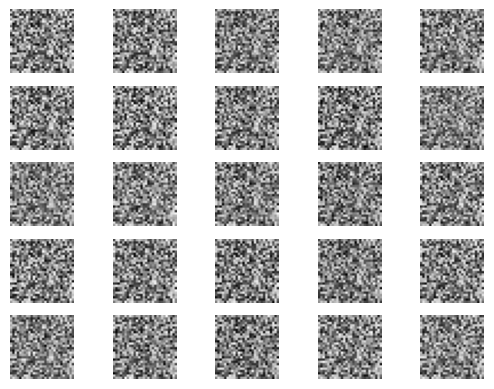

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
102/1000 [D loss: 3.313479423522949, acc.: 6.822328090667725] [G loss: 0.03895065560936928]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
103/1000 [D loss: 3.323289155960083, acc.: 6.816864013671875] [G loss: 0.038587749004364014]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
104/1000 [D loss: 3.333273410797119, acc.: 6.796728134155273] [G loss: 0.03823080658912659]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
105/1000 [D loss: 3.3436336517333984, acc.: 6.762331962585449] [G loss: 0.03787839785218239]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
106/1000 [D loss: 3.353829860687256, acc.: 6.728574752807617] [G loss: 0.037534911185503006]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
107/1000 [D loss: 3.363600254058838, acc.: 6.709805011749268] [G loss: 0.03719698637723923]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
108/1000 [D loss: 3.373542070388794, acc.: 6.705615520477295] [G loss: 0.0368642620742321]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
109/1000 [D loss: 3.383030414581299, acc.: 6.72971

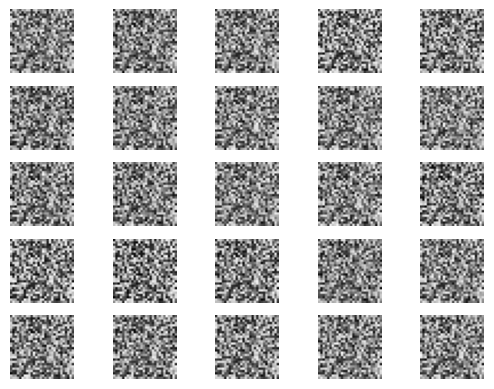

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
202/1000 [D loss: 3.9910192489624023, acc.: 6.464733123779297] [G loss: 0.020048703998327255]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
203/1000 [D loss: 3.995950698852539, acc.: 6.456053256988525] [G loss: 0.01995195262134075]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
204/1000 [D loss: 4.000905990600586, acc.: 6.462645530700684] [G loss: 0.01985599659383297]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
205/1000 [D loss: 4.005979061126709, acc.: 6.469175338745117] [G loss: 0.01976105384528637]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
206/1000 [D loss: 4.010609149932861, acc.: 6.460598945617676] [G loss: 0.019667206332087517]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
207/1000 [D loss: 4.014792442321777, acc.: 6.474560737609863] [G loss: 0.019573839381337166]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
208/1000 [D loss: 4.0194478034973145, acc.: 6.488389015197754] [G loss: 0.019481636583805084]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
209/1000 [D loss: 4.0239410400390625, acc.: 6.

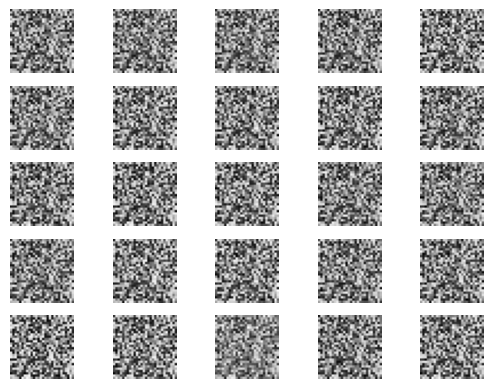

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
302/1000 [D loss: 4.373427391052246, acc.: 6.460909366607666] [G loss: 0.013503042049705982]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
303/1000 [D loss: 4.376213073730469, acc.: 6.4653449058532715] [G loss: 0.013459164649248123]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
304/1000 [D loss: 4.379571437835693, acc.: 6.46975040435791] [G loss: 0.013415519148111343]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
305/1000 [D loss: 4.383045196533203, acc.: 6.463940620422363] [G loss: 0.013372109271585941]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
306/1000 [D loss: 4.385903358459473, acc.: 6.46832275390625] [G loss: 0.013328928500413895]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
307/1000 [D loss: 4.388838768005371, acc.: 6.482797622680664] [G loss: 0.013286085799336433]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
308/1000 [D loss: 4.3915815353393555, acc.: 6.492135047912598] [G loss: 0.013243538327515125]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
309/1000 [D loss: 4.39450740814209, acc.: 6.4

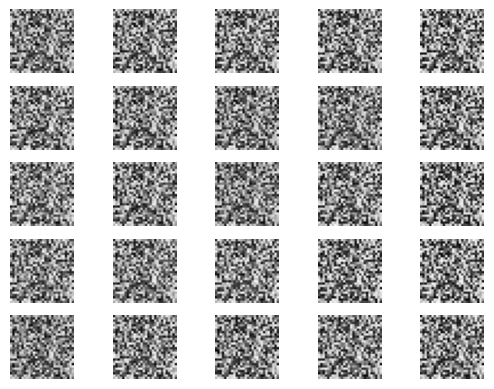

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
402/1000 [D loss: 4.644854545593262, acc.: 6.5673394203186035] [G loss: 0.010180570185184479]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
403/1000 [D loss: 4.647218704223633, acc.: 6.558835506439209] [G loss: 0.01015556138008833]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
404/1000 [D loss: 4.6493449211120605, acc.: 6.55037260055542] [G loss: 0.01013069786131382]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
405/1000 [D loss: 4.651555061340332, acc.: 6.553475379943848] [G loss: 0.010105987079441547]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
406/1000 [D loss: 4.653918743133545, acc.: 6.568058490753174] [G loss: 0.010081354528665543]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
407/1000 [D loss: 4.656177997589111, acc.: 6.56345796585083] [G loss: 0.01005688775330782]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
408/1000 [D loss: 4.658272743225098, acc.: 6.551252841949463] [G loss: 0.010032560676336288]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
409/1000 [D loss: 4.660627365112305, acc.: 6.561

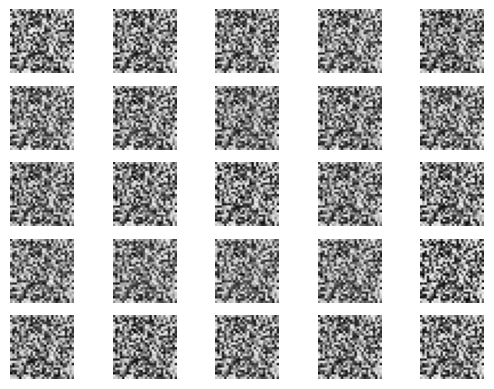

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
502/1000 [D loss: 4.853443145751953, acc.: 6.519852638244629] [G loss: 0.00817115604877472]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
503/1000 [D loss: 4.8553619384765625, acc.: 6.528604984283447] [G loss: 0.008155048824846745]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
504/1000 [D loss: 4.857229232788086, acc.: 6.524964332580566] [G loss: 0.008139016106724739]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
505/1000 [D loss: 4.859025955200195, acc.: 6.52133846282959] [G loss: 0.008123022504150867]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
506/1000 [D loss: 4.860701084136963, acc.: 6.523881912231445] [G loss: 0.008107107132673264]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
507/1000 [D loss: 4.862537384033203, acc.: 6.52641487121582] [G loss: 0.00809126440435648]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
508/1000 [D loss: 4.8644914627075195, acc.: 6.538133144378662] [G loss: 0.008075540885329247]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
509/1000 [D loss: 4.866325855255127, acc.: 6.53

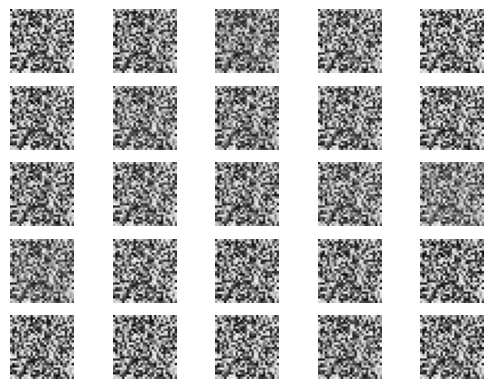

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
602/1000 [D loss: 5.022870063781738, acc.: 6.5476202964782715] [G loss: 0.006824198178946972]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
603/1000 [D loss: 5.02440071105957, acc.: 6.544543743133545] [G loss: 0.006812963634729385]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
604/1000 [D loss: 5.026041030883789, acc.: 6.544057846069336] [G loss: 0.00680176354944706]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
605/1000 [D loss: 5.027583599090576, acc.: 6.54357385635376] [G loss: 0.00679060397669673]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
606/1000 [D loss: 5.029116630554199, acc.: 6.548232078552246] [G loss: 0.00677949795499444]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
607/1000 [D loss: 5.03068733215332, acc.: 6.545175552368164] [G loss: 0.006768404971808195]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
608/1000 [D loss: 5.032190322875977, acc.: 6.557504653930664] [G loss: 0.006757351569831371]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
609/1000 [D loss: 5.033871173858643, acc.: 6.55188

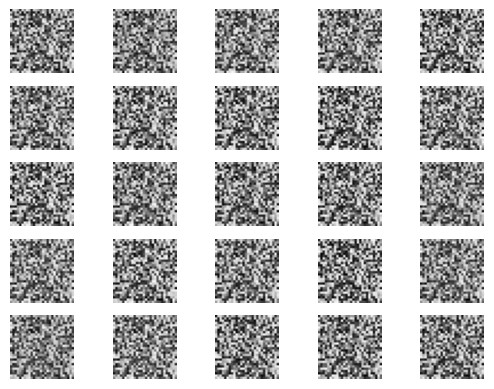

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
702/1000 [D loss: 5.165004253387451, acc.: 6.511990070343018] [G loss: 0.0058586206287145615]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
703/1000 [D loss: 5.166346073150635, acc.: 6.513835430145264] [G loss: 0.005850339308381081]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
704/1000 [D loss: 5.167545318603516, acc.: 6.509034156799316] [G loss: 0.005842077080160379]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
705/1000 [D loss: 5.168814659118652, acc.: 6.515300273895264] [G loss: 0.005833842791616917]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
706/1000 [D loss: 5.170105934143066, acc.: 6.52596378326416] [G loss: 0.005825629457831383]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
707/1000 [D loss: 5.171353340148926, acc.: 6.525574684143066] [G loss: 0.005817442201077938]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
708/1000 [D loss: 5.172637939453125, acc.: 6.522984027862549] [G loss: 0.005809280090034008]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
709/1000 [D loss: 5.173943519592285, acc.: 6.

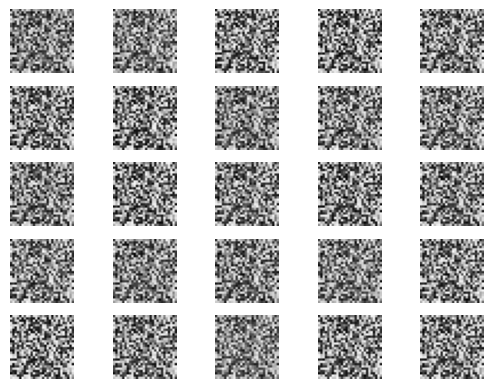

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
802/1000 [D loss: 5.28922176361084, acc.: 6.510498523712158] [G loss: 0.005132507532835007]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
803/1000 [D loss: 5.290255546569824, acc.: 6.506290912628174] [G loss: 0.0051261503249406815]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
804/1000 [D loss: 5.291450023651123, acc.: 6.50403356552124] [G loss: 0.005119815468788147]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
805/1000 [D loss: 5.292636871337891, acc.: 6.503719329833984] [G loss: 0.005113493651151657]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
806/1000 [D loss: 5.293769836425781, acc.: 6.50340461730957] [G loss: 0.005107192322611809]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
807/1000 [D loss: 5.294897556304932, acc.: 6.50502347946167] [G loss: 0.005100897513329983]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
808/1000 [D loss: 5.296063423156738, acc.: 6.504708290100098] [G loss: 0.005094623193144798]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
809/1000 [D loss: 5.297137260437012, acc.: 6.514

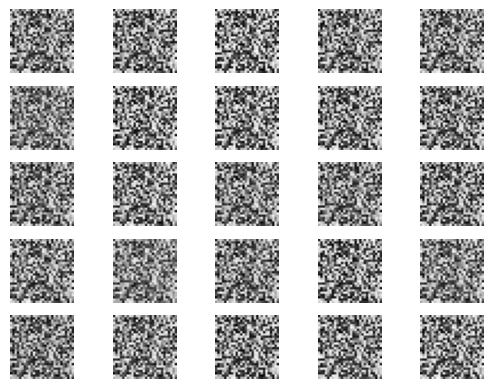

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
902/1000 [D loss: 5.3961591720581055, acc.: 6.509336948394775] [G loss: 0.004566583316773176]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
903/1000 [D loss: 5.397077560424805, acc.: 6.507322788238525] [G loss: 0.004561554174870253]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
904/1000 [D loss: 5.397980213165283, acc.: 6.508763790130615] [G loss: 0.004556533880531788]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
905/1000 [D loss: 5.3989105224609375, acc.: 6.510201930999756] [G loss: 0.004551529884338379]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
906/1000 [D loss: 5.400086402893066, acc.: 6.509914875030518] [G loss: 0.0045465389266610146]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
907/1000 [D loss: 5.401280403137207, acc.: 6.513068199157715] [G loss: 0.004541551228612661]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
908/1000 [D loss: 5.402393341064453, acc.: 6.51793098449707] [G loss: 0.004536581225693226]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
909/1000 [D loss: 5.4034600257873535, acc.:

In [ ]:
train(epochs=1000, batch_size=64, save_interval=100)